# 01 데이터 점검·전처리
> 원본 zip은 수정하지 않음. 전처리 결과는 `preprocessed/`에 저장

### 0-1. 셋업
- 목적: 경로·라이브러리 준비
- TODO: zip 2개·`preprocessed/` 경로 상수, import, 한글 폰트
- 확인: zip 존재 여부, 폰트 적용

In [1]:
# 기본 라이브러리
import io
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 표시 옵션
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.3f}'.format)

# 한글 폰트 (Windows 기본 맑은 고딕) + 마이너스 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트: 현재 위치에서 위로 올라가며 dataset 폴더가 있는 곳을 찾음
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'dataset').is_dir())
DATA_DIR = ROOT / 'dataset'
CONTEST_ZIP = DATA_DIR / '01_대회제공_카드유동인구_202507-202512.zip'  # 대회 제공 데이터
WEATHER_ZIP = DATA_DIR / '02_기상관측_ASOS_AWS_197507-202512.zip'      # 기상청 ASOS·AWS 수집본
OUT_DIR = ROOT / 'notebooks' / 'preprocessed'          # 전처리 결과 저장 위치
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 분석 기간 (카드·유동인구 공통)
START, END = pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31')
ALL_DAYS = pd.date_range(START, END, freq='D')

for p in [CONTEST_ZIP, WEATHER_ZIP]:
    size = f'{p.stat().st_size / 1e6:,.1f} MB' if p.exists() else '-'
    print(f'{p.name}: {"있음" if p.exists() else "없음"} ({size})')
print('저장 경로:', OUT_DIR)

2026빅콘테스트_제공_데이터.zip: 있음 (60.8 MB)
기상자료.zip: 있음 (60.6 MB)
저장 경로: D:\climate_recovery\notebooks\preprocessed


### 0-2. zip 로더
- 목적: 압축 해제 없이 파일 읽기
- TODO: cp949 파일명 디코딩, 파일 목록 출력, 인코딩·구분자 지정 로더 함수
- 확인: zip 내부 파일 목록·크기

In [2]:
def decode_name(info):
    """zip 내부 파일명 복원: UTF-8 플래그가 없으면 cp949로 저장된 한글 파일명"""
    if info.flag_bits & 0x800:
        return info.filename
    try:
        return info.filename.encode('cp437').decode('cp949')
    except UnicodeError:
        return info.filename


def zip_index(zip_path):
    """zip 열기 → (ZipFile, {복원된 경로: ZipInfo})"""
    zf = zipfile.ZipFile(zip_path)
    return zf, {decode_name(i): i for i in zf.infolist() if not i.is_dir()}


def find_member(index, pattern):
    """경로에 pattern이 포함된 파일을 정확히 1개 찾음 (0개·여러 개면 에러)"""
    hits = [k for k in index if pattern in k]
    if len(hits) != 1:
        raise ValueError(f'{pattern}: {len(hits)}개 매칭 {hits[:3]}')
    return hits[0]


def read_zip_csv(zf, index, pattern, **kwargs):
    """zip 안의 csv/txt를 압축 해제 없이 DataFrame으로 읽기"""
    with zf.open(index[find_member(index, pattern)]) as f:
        return pd.read_csv(f, **kwargs)


def read_xlsx_rows(zf, index, pattern):
    """openpyxl 없이 xlsx 내부 XML을 직접 파싱 → {시트파일명: 행 리스트}"""
    ns = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
    x = zipfile.ZipFile(io.BytesIO(zf.read(index[find_member(index, pattern)])))
    # 공유 문자열 테이블 (셀에는 인덱스만 저장됨)
    shared = []
    if 'xl/sharedStrings.xml' in x.namelist():
        root = ET.fromstring(x.read('xl/sharedStrings.xml'))
        shared = [''.join(t.text or '' for t in si.iter(f'{ns}t')) for si in root.findall(f'{ns}si')]

    def col_idx(ref):
        """셀 주소(예: 'C5') → 0부터 시작하는 열 번호"""
        n = 0
        for ch in re.match(r'[A-Z]+', ref).group():
            n = n * 26 + ord(ch) - 64
        return n - 1

    sheets = {}
    for name in sorted(n for n in x.namelist() if n.startswith('xl/worksheets/sheet')):
        rows = []
        for row in ET.fromstring(x.read(name)).iter(f'{ns}row'):
            vals = {}
            for c in row.findall(f'{ns}c'):
                v = c.find(f'{ns}v')
                if v is not None:
                    text = shared[int(v.text)] if c.get('t') == 's' else v.text
                else:  # 인라인 문자열
                    text = ''.join(t.text or '' for t in c.iter(f'{ns}t'))
                vals[col_idx(c.get('r'))] = (text or '').strip()
            # 빈 셀이 생략되므로 열 위치를 보존해 리스트로 복원
            rows.append([vals.get(i, '') for i in range(max(vals) + 1)] if vals else [])
        sheets[name.split('/')[-1]] = rows
    return sheets


# 두 zip의 파일 목록 인덱스 생성
contest_zf, contest_idx = zip_index(CONTEST_ZIP)
weather_zf, weather_idx = zip_index(WEATHER_ZIP)

# 대회 데이터: 파일 단위 목록
contest_files = pd.DataFrame([
    {'폴더': k.rsplit('/', 1)[0].split('/')[-1], '파일': k.rsplit('/', 1)[-1], 'MB': i.file_size / 1e6}
    for k, i in contest_idx.items()
])
display(contest_files)

# 기상자료: 파일이 5만 개 이상이라 상위 폴더 단위로 요약
wx_sizes = pd.Series({k: i.file_size for k, i in weather_idx.items()})
wx_folder = wx_sizes.groupby(lambda k: '/'.join(k.split('/')[:2])).agg(파일수='count', MB='sum')
wx_folder['MB'] = wx_folder['MB'] / 1e6
display(wx_folder.sort_values('파일수', ascending=False))

,폴더,파일,MB
0,신한카드,2026빅콘테스트_신한카드_데이터_레이아웃_안_20260903.xlsx,0.014
1,신한카드,신한카드_빅콘테스트2026_데이터1.txt,63.264
2,신한카드,신한카드_빅콘테스트2026_데이터2.txt,50.038
3,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202507.csv,10.957
4,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202508.csv,11.095
5,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202509.csv,11.033
6,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202510.csv,11.247
7,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202511.csv,11.143
8,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_age_pop_202512.csv,10.884
9,2026빅콘테스트_sk통신인구_데이터_레이아웃,flow_time_pop_202507.csv,15.495


,파일수,MB
기상자료/.캐시AWS,48586,23.311
기상자료/원자료,999,4.803
기상자료/시간자료,942,47.210
기상자료/.캐시,724,281.888
기상자료/_v1산출물_백업,520,11.427
기상자료/통합자료,15,51.312
기상자료/점검,14,0.092
기상자료/점검기록,12,0.537
기상자료/__pycache__,3,0.078
기상자료/.env.example,1,0.000


## 1. 신한카드 데이터1

### 1-1. 로드·레이아웃 대조
- 목적: 데이터1 구조 확인
- TODO: cp949·탭·dtype=str 로드 → 레이아웃 8열과 비교
- 확인: shape, 열 일치 여부

In [3]:
# 데이터1: cp949 인코딩 · 탭 구분. 원본 상태를 보기 위해 전부 문자열로 읽음 (빈 값도 NaN 변환 안 함)
card1_raw = read_zip_csv(contest_zf, contest_idx, '데이터1.txt',
                         sep='\t', encoding='cp949', dtype=str, keep_default_na=False)
print('데이터1 shape:', card1_raw.shape)
display(card1_raw.head())

# 레이아웃 xlsx에서 컬럼 정의 추출 (sheet1 = 데이터1, sheet2 = 데이터2)
layout_sheets = read_xlsx_rows(contest_zf, contest_idx, '데이터_레이아웃_안')


def layout_columns(rows):
    """'구분' 헤더 아래에서 (컬럼명, 한글명) 목록 추출 (표가 시작하는 열 위치를 찾아 맞춤)"""
    start, j = next((i, r.index('구분')) for i, r in enumerate(rows) if '구분' in r)
    return [(r[j + 1], r[j + 2]) for r in rows[start + 1:] if len(r) > j + 2 and r[j].isdigit()]


def compare_columns(layout_cols, df):
    """레이아웃 컬럼 vs 실제 컬럼 대조표"""
    names = [c for c, _ in layout_cols]
    rows = [{'컬럼': c, '한글명': k, '실제 존재': c in df.columns} for c, k in layout_cols]
    rows += [{'컬럼': c, '한글명': '(레이아웃에 없음)', '실제 존재': True} for c in df.columns if c not in names]
    return pd.DataFrame(rows)


LAYOUT1 = layout_columns(layout_sheets['sheet1.xml'])
LAYOUT2 = layout_columns(layout_sheets['sheet2.xml'])
display(compare_columns(LAYOUT1, card1_raw))

데이터1 shape: (1044710, 8)


,TA_YMD,TIME_GB,MCT_SGG_CD,MCT_RY_CD,SEX_CCD,AGE_CCD,TS_AT,USE_CNT
0,20250704,12_17,서울 강남구,가구,법인,법인,15477163,16
1,20250721,12_17,서울 강남구,가구,법인,법인,308451,38
2,20250703,12_17,서울 강남구,가구,여성,20 대,78970,5
3,20250703,18_23,서울 강남구,가구,남성,20 대,271220,5
4,20250706,18_23,서울 강남구,가구,여성,20 대,260872,5


,컬럼,한글명,실제 존재
0,TA_YMD,기준일자,True
1,TIME_GB,시간대,True
2,MCT_SGG_CD,가맹점 위치정보(시·군·구),True
3,MCT_RY_CD,가맹점 업종,True
4,SEX_CCD,이용고객 성별,True
5,AGE_CCD,이용고객 연령대,True
6,TS_AT,결제금액 합계,True
7,USE_CNT,결제건수 합계,True


### 1-2. 타입 변환
- 목적: 분석 가능한 타입으로 변환
- TODO: TA_YMD→날짜, TS_AT·USE_CNT→숫자, AGE_CCD 공백 정리
- 확인: dtypes, 변환 실패 건수

In [4]:
card1 = card1_raw.copy()

# 날짜: 'YYYYMMDD' 문자열 → datetime
card1['DATE'] = pd.to_datetime(card1['TA_YMD'], format='%Y%m%d', errors='coerce')

# 금액·건수: 문자열(VARCHAR) → 숫자
for c in ['TS_AT', 'USE_CNT']:
    card1[c] = pd.to_numeric(card1[c], errors='coerce')

# 연령대 표기 정리: '20 대' → '20대'
card1['AGE_CCD'] = card1['AGE_CCD'].str.replace(' ', '', regex=False)

# 변환 실패 = 원본은 값이 있었는데 변환 후 NaN이 된 건수
conv_fail = pd.Series({
    'TA_YMD→DATE': (card1['DATE'].isna() & card1_raw['TA_YMD'].ne('')).sum(),
    'TS_AT': (card1['TS_AT'].isna() & card1_raw['TS_AT'].ne('')).sum(),
    'USE_CNT': (card1['USE_CNT'].isna() & card1_raw['USE_CNT'].ne('')).sum(),
}, name='변환 실패 건수')
display(conv_fail.to_frame())

# 값 종류가 적은 컬럼은 category로 바꿔 메모리 절약
CARD_CAT = ['TIME_GB', 'MCT_SGG_CD', 'MCT_RY_CD', 'SEX_CCD', 'AGE_CCD']
print('카테고리 값:')
for c in CARD_CAT:
    u = card1[c].unique()
    print(f'  {c} ({len(u)}개):', list(u)[:12], '...' if len(u) > 12 else '')
card1 = card1.drop(columns='TA_YMD')
card1[CARD_CAT] = card1[CARD_CAT].astype('category')
print(card1.dtypes)

,변환 실패 건수
TA_YMD→DATE,0
TS_AT,0
USE_CNT,0


카테고리 값:
  TIME_GB (4개): ['12_17', '18_23', '06_11', '00_05'] 
  MCT_SGG_CD (2개): ['서울 강남구', '강원 춘천시'] 
  MCT_RY_CD (91개): ['가구', '가전', '보험', '서점', '약국', '양식', '일식', '중식', '택시', '한식', '화원', '노래방'] ...
  SEX_CCD (3개): ['법인', '여성', '남성'] 
  AGE_CCD (10개): ['법인', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '10대', '90대'] 


TIME_GB             category
MCT_SGG_CD          category
MCT_RY_CD           category
SEX_CCD             category
AGE_CCD             category
TS_AT                  int64
USE_CNT                int64
DATE          datetime64[ns]
dtype: object


### 1-3. 결측 확인·처리
- 목적: 결측 규모 파악 후 처리
- TODO: 열별 NaN·빈 문자열 집계 → 처리 규칙 결정·적용
- 확인: 처리 전/후 결측 수·행 수

In [5]:
# 결측 = 원본 빈 문자열 + 변환 후 NaN
na_table = pd.DataFrame({
    '빈문자열(원본)': card1_raw.eq('').sum(),
    'NaN(변환 후)': pd.Series({
        'TA_YMD': card1['DATE'].isna().sum(),
        **{c: card1[c].isna().sum() for c in ['TS_AT', 'USE_CNT']},
        **{c: card1[c].astype(str).eq('').sum() for c in CARD_CAT},
    }),
})
display(na_table)

# 처리 규칙: 키(날짜·구분값) 또는 값(금액·건수)이 없는 행은 집계 단위를 알 수 없으므로 제거
n_before = len(card1)
card1 = card1.dropna(subset=['DATE', 'TS_AT', 'USE_CNT'])
card1 = card1[card1[CARD_CAT].astype(str).ne('').all(axis=1)]
print(f'결측 처리: {n_before:,} → {len(card1):,}행 (제거 {n_before - len(card1):,})')

,빈문자열(원본),NaN(변환 후)
AGE_CCD,0,0
MCT_RY_CD,0,0
MCT_SGG_CD,0,0
SEX_CCD,0,0
TA_YMD,0,0
TIME_GB,0,0
TS_AT,0,0
USE_CNT,0,0


결측 처리: 1,044,710 → 1,044,710행 (제거 0)


### 1-4. 중복 확인·제거
- 목적: 중복 행 제거
- TODO: 완전 중복 vs 키(날짜·시간대·지역·업종·성별·연령) 중복 구분 → 제거
- 확인: 중복 건수, 키 중복 시 값 차이

In [6]:
# 집계 키: 날짜 × 시간대 × 가맹점 지역 × 업종 × 성별 × 연령
CARD1_KEY = ['DATE', 'TIME_GB', 'MCT_SGG_CD', 'MCT_RY_CD', 'SEX_CCD', 'AGE_CCD']

full_dup = card1.duplicated().sum()                      # 모든 컬럼이 같은 행
key_dup = card1.duplicated(CARD1_KEY, keep=False)        # 키만 같은 행 (값은 다를 수 있음)
print(f'완전 중복: {full_dup:,}행 / 키 중복(관련 행 전체): {key_dup.sum():,}행')
if key_dup.any():
    display(card1[key_dup].sort_values(CARD1_KEY).head(10))

# 처리 규칙
#  - 완전 중복: 같은 기록이 두 번 들어간 것으로 보고 1개만 남김
#  - 키 중복 + 값 다름: 같은 집계 단위가 쪼개진 기록으로 보고 합산
n_before = len(card1)
card1 = card1.drop_duplicates()
if card1.duplicated(CARD1_KEY).any():
    card1 = card1.groupby(CARD1_KEY, observed=True, as_index=False)[['TS_AT', 'USE_CNT']].sum()
card1 = card1.reset_index(drop=True)
print(f'중복 처리: {n_before:,} → {len(card1):,}행')

완전 중복: 0행 / 키 중복(관련 행 전체): 0행


중복 처리: 1,044,710 → 1,044,710행


### 1-5. 법인 행
- 목적: 법인 결제 처리 방침 결정
- TODO: SEX·AGE='법인' 건수·금액 비중 → 포함 여부 플래그
- 확인: 법인 비중, 업종별 편중

In [7]:
# 법인 결제는 성별·연령 모두 '법인'으로 들어옴 → 두 컬럼이 항상 같이 '법인'인지 확인
display(pd.crosstab(card1['SEX_CCD'].astype(str).eq('법인'), card1['AGE_CCD'].astype(str).eq('법인'),
                    rownames=['SEX=법인'], colnames=['AGE=법인']))

card1['IS_CORP'] = card1['SEX_CCD'].astype(str).eq('법인')

# 전체 비중 (행·매출·건수)
corp_share = pd.Series({
    '행 비중': card1['IS_CORP'].mean(),
    '매출 비중': card1.loc[card1['IS_CORP'], 'TS_AT'].sum() / card1['TS_AT'].sum(),
    '건수 비중': card1.loc[card1['IS_CORP'], 'USE_CNT'].sum() / card1['USE_CNT'].sum(),
}, name='법인')
display(corp_share.to_frame())

# 업종별 법인 매출 비중 상위 → 어떤 업종에 쏠려 있는지
ind_corp = card1.pivot_table(index='MCT_RY_CD', columns='IS_CORP', values='TS_AT',
                             aggfunc='sum', observed=True, fill_value=0)
ind_corp['법인 매출비중'] = ind_corp[True] / ind_corp.sum(axis=1)
display(ind_corp.sort_values('법인 매출비중', ascending=False).head(15))

# 처리 방침: 삭제하지 않고 IS_CORP 플래그로 보존 (02에서는 개인 결제만 기본 사용)

AGE=법인,False,True
SEX=법인,,
False,983413,0
True,0,61297


,법인
행 비중,0.059
매출 비중,0.159
건수 비중,0.066


IS_CORP,False,True,법인 매출비중
MCT_RY_CD,,,
"통신요금(PC통신,무선호출)",0,9621725380,1.000
사무기기/문구용품,15790961805,44134490715,0.736
부동산중개,327736400,440964052,0.574
호텔/콘도,85975176932,106685245143,0.554
유흥업소,49607171182,55009471319,0.526
"모텔,여관,기타숙박",24013803928,23334562681,0.493
주류판매,13487859465,12767491486,0.486
양식,152988679237,116244245213,0.432
주차장,10494019500,7636031941,0.421


### 1-6. 소건수 마스킹
- 목적: 5건 미만 절단 영향 파악
- TODO: USE_CNT 최솟값·분포, 업종·시간대별 소건수 비중
- 확인: 절단 정황, 영향 큰 업종

USE_CNT 최솟값: 5


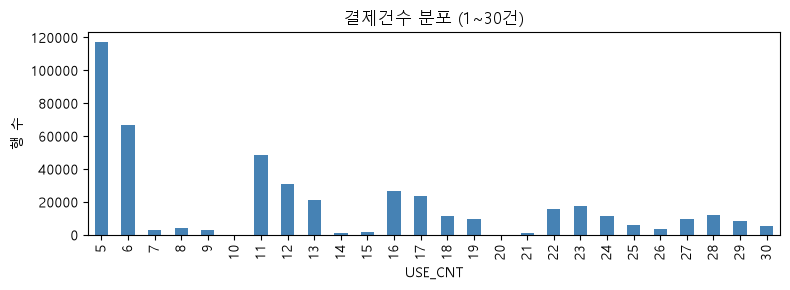

,소건수 행 비중(시간대)
TIME_GB,
00_05,0.310
06_11,0.199
12_17,0.143
18_23,0.179


,소건수 행 비중(연령)
AGE_CCD,
10대,0.273
20대,0.168
30대,0.137
40대,0.135
50대,0.144
60대,0.184
70대,0.232
80대,0.316
90대,0.517


,소건수 행 비중(업종 상위)
MCT_RY_CD,
중고차판매,0.929
장례식장/묘지/장의사,0.688
오토바이,0.668
택시,0.654
안마/마사지,0.653
부동산중개,0.653
수제용품점,0.596
중고품판매점,0.582
가구,0.576


In [8]:
# 건수 최솟값이 5면 '5건 미만 조합은 제공하지 않음(비식별 처리)'으로 추정
print('USE_CNT 최솟값:', card1['USE_CNT'].min())

fig, ax = plt.subplots(figsize=(8, 3))
card1['USE_CNT'].value_counts().sort_index().loc[:30].plot.bar(ax=ax, color='steelblue')
ax.set(title='결제건수 분포 (1~30건)', xlabel='USE_CNT', ylabel='행 수')
plt.tight_layout(); plt.show()

# 소건수(5~9건) 행 비중: 절단 영향이 클수록 비중이 높음
small = card1['USE_CNT'] < 10
display(small.groupby(card1['TIME_GB'], observed=True).mean().rename('소건수 행 비중(시간대)').to_frame())
display(small.groupby(card1['AGE_CCD'], observed=True).mean().rename('소건수 행 비중(연령)').to_frame())
display(small.groupby(card1['MCT_RY_CD'], observed=True).mean()
        .sort_values(ascending=False).head(15).rename('소건수 행 비중(업종 상위)').to_frame())

### 1-7. 이상치
- 목적: 극단 매출 행 식별
- TODO: TS_AT·건당단가 로그 분포, 상위 극값 행 조회 → 플래그
- 확인: 극값 업종·날짜, 처리 기준

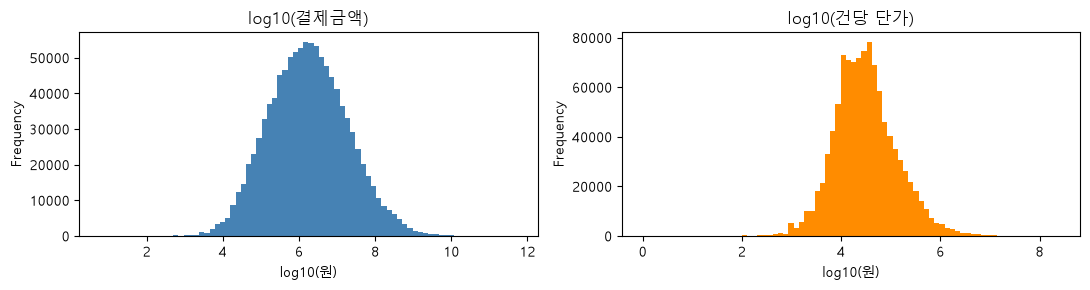

,DATE,TIME_GB,MCT_SGG_CD,MCT_RY_CD,SEX_CCD,AGE_CCD,TS_AT,USE_CNT,UNIT_PRICE
266988,2025-08-06,12_17,서울 강남구,ZZ_나머지,법인,법인,520512895491,16270,"31,992,187.799"
475447,2025-09-04,12_17,서울 강남구,ZZ_나머지,법인,법인,299091722044,19579,"15,276,149.039"
840662,2025-12-29,12_17,서울 강남구,세금공과금,남성,60대,289646721166,7773,"37,263,182.962"
671046,2025-10-10,12_17,서울 강남구,ZZ_나머지,법인,법인,173658599830,13753,"12,626,961.378"
95643,2025-07-04,12_17,서울 강남구,ZZ_나머지,법인,법인,160960081300,16069,"10,016,807.598"
983605,2025-12-04,12_17,서울 강남구,ZZ_나머지,법인,법인,118230904057,20916,"5,652,653.665"
741221,2025-11-06,12_17,서울 강남구,ZZ_나머지,법인,법인,95442109367,16879,"5,654,488.380"
953360,2025-12-01,06_11,서울 강남구,세금공과금,법인,법인,64874808897,261,"248,562,486.195"
541960,2025-10-27,06_11,서울 강남구,세금공과금,법인,법인,57981146108,247,"234,741,482.219"
742126,2025-11-10,12_17,서울 강남구,세금공과금,법인,법인,43090355024,646,"66,703,335.950"


이상치 플래그: 2,175행 (0.21%), 매출 비중 4.25%


,이상치 행 수(업종)
MCT_RY_CD,
싸우나/목욕탕,139
여행사/항공사,130
보건소,122
헬스장,115
기타요식,97
독서실,93
생활잡화/수입상품점,71
게임방/오락실,57
예식장/결혼서비스,55


In [9]:
# 건당 단가
card1['UNIT_PRICE'] = card1['TS_AT'] / card1['USE_CNT']

# 로그 분포
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
np.log10(card1['TS_AT']).plot.hist(bins=80, ax=axes[0], color='steelblue')
axes[0].set(title='log10(결제금액)', xlabel='log10(원)')
np.log10(card1['UNIT_PRICE']).plot.hist(bins=80, ax=axes[1], color='darkorange')
axes[1].set(title='log10(건당 단가)', xlabel='log10(원)')
plt.tight_layout(); plt.show()

# 금액 상위 극값 행
display(card1.nlargest(10, 'TS_AT')[['DATE', 'TIME_GB', 'MCT_SGG_CD', 'MCT_RY_CD', 'SEX_CCD', 'AGE_CCD',
                                     'TS_AT', 'USE_CNT', 'UNIT_PRICE']])

# 플래그 기준: 같은 셀(업종·지역·시간대·성별·연령)의 날짜별 값끼리 비교해
#            log(금액)의 robust z = 0.6745·(x−중앙값)/MAD 가 5를 넘으면 이상치
CELL = ['MCT_RY_CD', 'MCT_SGG_CD', 'TIME_GB', 'SEX_CCD', 'AGE_CCD']
groups = [card1[c] for c in CELL]
log_ts = np.log(card1['TS_AT'])
med = log_ts.groupby(groups, observed=True).transform('median')
mad = (log_ts - med).abs().groupby(groups, observed=True).transform('median')
robust_z = 0.6745 * (log_ts - med) / mad.replace(0, np.nan)
card1['IS_OUTLIER'] = robust_z.gt(5).fillna(False)

print(f"이상치 플래그: {card1['IS_OUTLIER'].sum():,}행 "
      f"({card1['IS_OUTLIER'].mean():.2%}), 매출 비중 {card1.loc[card1['IS_OUTLIER'], 'TS_AT'].sum() / card1['TS_AT'].sum():.2%}")
display(card1.loc[card1['IS_OUTLIER'], 'MCT_RY_CD'].value_counts().head(10).rename('이상치 행 수(업종)').to_frame())
# 처리 방침: 삭제하지 않고 플래그만 부여 (02에서 포함/제외 민감도 비교)

### 1-8. 날짜 커버리지
- 목적: 누락 일자 확인
- TODO: 날짜×지역×시간대 행 존재 매트릭스
- 확인: 184일 완전성, 누락 일자

TIME_GB,00_05,06_11,12_17,18_23
MCT_SGG_CD,,,,
강원 춘천시,184,184,184,184
서울 강남구,184,184,184,184


강원 춘천시 누락 일자 0개: []
서울 강남구 누락 일자 0개: []


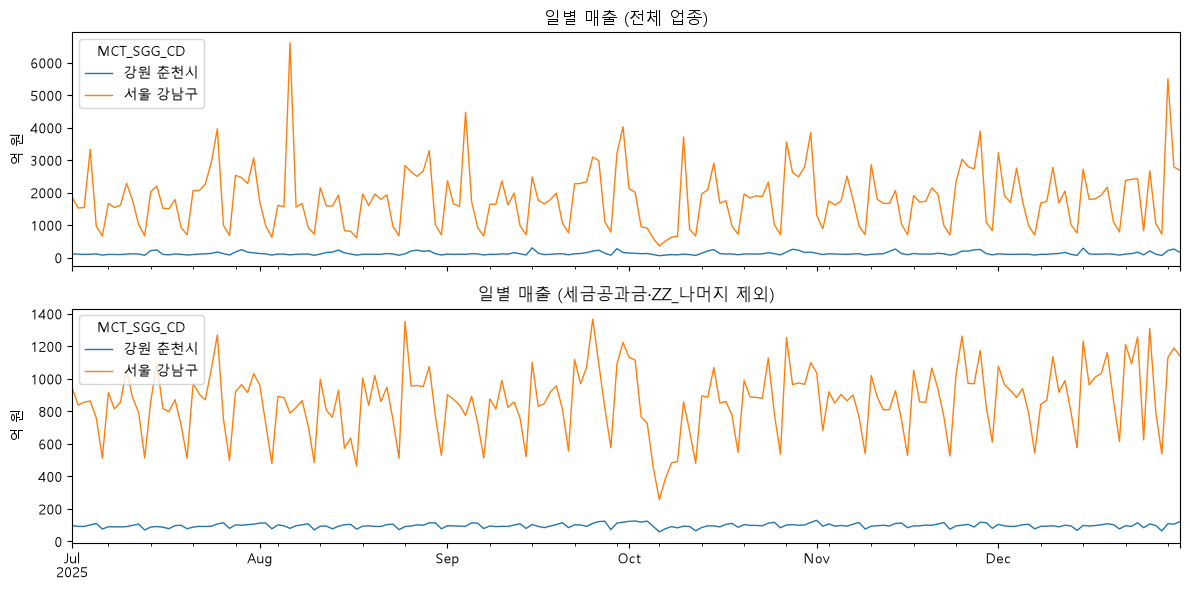

In [10]:
# 지역 × 시간대별로 184일이 모두 있는지
cov = card1.groupby(['MCT_SGG_CD', 'TIME_GB'], observed=True)['DATE'].nunique().unstack()
display(cov)

# 누락 일자 목록
for region, g in card1.groupby('MCT_SGG_CD', observed=True):
    missing = ALL_DAYS.difference(g['DATE'].unique())
    print(f'{region} 누락 일자 {len(missing)}개:', list(missing.strftime('%m-%d')))

# 일별 매출 추이: 규모가 큰 비소매 결제(세금공과금·ZZ_나머지)를 뺀 값도 함께 확인
non_retail = card1['MCT_RY_CD'].astype(str).isin(['세금공과금', 'ZZ_나머지'])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (label, mask) in zip(axes, [('전체 업종', slice(None)), ('세금공과금·ZZ_나머지 제외', ~non_retail)]):
    daily = card1.loc[mask].groupby(['DATE', 'MCT_SGG_CD'], observed=True)['TS_AT'].sum().unstack() / 1e8
    daily.plot(ax=ax, lw=1)
    ax.set(title=f'일별 매출 ({label})', ylabel='억 원', xlabel='')
plt.tight_layout(); plt.show()

### 1-9. 업종 분포·등급
- 목적: 분석 신뢰도별 업종 구분
- TODO: 업종별 매출·건수·데이터 있는 날 비율 → 등급(A/B/보류)
- 확인: 91개 업종 등급표

In [11]:
# 업종 × 지역 요약
N_DAYS = len(ALL_DAYS)
ind_stat = (card1.groupby(['MCT_RY_CD', 'MCT_SGG_CD'], observed=True)
            .agg(매출=('TS_AT', 'sum'), 건수=('USE_CNT', 'sum'),
                 데이터일수=('DATE', 'nunique'), 행수=('TS_AT', 'size'))
            .reset_index())
ind_stat['일커버리지'] = ind_stat['데이터일수'] / N_DAYS
ind_stat['일평균건수'] = ind_stat['건수'] / N_DAYS
ind_stat['매출비중'] = ind_stat['매출'] / ind_stat.groupby('MCT_SGG_CD', observed=True)['매출'].transform('sum')

# 등급 규칙 (일별 분석 신뢰도 기준)
#  A   : 184일 중 95% 이상 데이터가 있고 일평균 100건 이상
#  B   : 80% 이상 데이터가 있음
#  보류: 그 외 (결측일이 많아 일별 편차가 노이즈에 좌우됨)
ind_stat['등급'] = np.select(
    [(ind_stat['일커버리지'] >= 0.95) & (ind_stat['일평균건수'] >= 100), ind_stat['일커버리지'] >= 0.8],
    ['A', 'B'], default='보류')

display(pd.crosstab(ind_stat['등급'], ind_stat['MCT_SGG_CD'], margins=True))
display(ind_stat.sort_values(['MCT_SGG_CD', '매출'], ascending=[True, False])
        .groupby('MCT_SGG_CD', observed=True).head(10))
display(ind_stat[ind_stat['등급'] == '보류'].sort_values('일커버리지'))

# 업종 × 지역 등급표 (91개 업종)
industry_grade = ind_stat.pivot(index='MCT_RY_CD', columns='MCT_SGG_CD', values='등급')
print('업종 수:', len(industry_grade))

MCT_SGG_CD,강원 춘천시,서울 강남구,All
등급,,,
A,57,78,135
B,18,8,26
보류,10,3,13
All,85,89,174


,MCT_RY_CD,MCT_SGG_CD,매출,건수,데이터일수,행수,일커버리지,일평균건수,매출비중,등급
2,ZZ_나머지,강원 춘천시,579375999839,1715233,184,9895,1.000,"9,321.918",0.244,A
158,한식,강원 춘천시,275136428468,6119021,184,11877,1.000,"33,255.549",0.116,A
162,할인점/슈퍼마켓/양판점,강원 춘천시,262025304143,7147376,184,10547,1.000,"38,844.435",0.110,A
127,주유소,강원 춘천시,163210205819,2880121,184,10075,1.000,"15,652.832",0.069,A
15,기타요식,강원 춘천시,102189186842,4326165,184,11461,1.000,"23,511.766",0.043,A
153,편의점,강원 춘천시,85321669329,11313936,184,12314,1.000,"61,488.783",0.036,A
72,실내/실외골프장,강원 춘천시,77270120492,430784,184,6813,1.000,"2,341.217",0.033,A
106,일반병원,강원 춘천시,67539777615,1434833,184,7703,1.000,"7,798.005",0.028,A
13,기타식품,강원 춘천시,60037764146,2256022,184,11004,1.000,"12,260.989",0.025,A
82,약국,강원 춘천시,40167589346,2002670,184,8811,1.000,"10,884.076",0.017,A


,MCT_RY_CD,MCT_SGG_CD,매출,건수,데이터일수,행수,일커버리지,일평균건수,매출비중,등급
47,부동산중개,강원 춘천시,24406490,15,3,3,0.016,0.082,0.000,보류
147,"통신요금(PC통신,무선호출)",서울 강남구,9621725380,202,6,6,0.033,1.098,0.000,보류
155,학교등록금,강원 춘천시,2248027027,1046,13,73,0.071,5.685,0.001,보류
61,쇼핑몰,강원 춘천시,7382489,96,17,19,0.092,0.522,0.000,보류
131,중고차판매,강원 춘천시,347630102,95,18,19,0.098,0.516,0.000,보류
132,중고차판매,서울 강남구,164414130,140,23,23,0.125,0.761,0.000,보류
45,보험,강원 춘천시,132343672,855,81,149,0.440,4.647,0.000,보류
125,주류판매,강원 춘천시,720621384,10370,97,319,0.527,56.359,0.000,보류
41,법률/사무서비스,강원 춘천시,844730548,1092,103,190,0.560,5.935,0.000,보류
86,여행사/항공사,강원 춘천시,703367562,1895,116,276,0.630,10.299,0.000,보류


업종 수: 91


### 1-10. 업종 매핑
- 목적: 분석용 업종 그룹 부여
- TODO: 논문 5그룹·대조군(세금공과금 등)·소매범위 컬럼 추가
- 확인: 그룹별 업종 수·매출 비중

In [12]:
# 논문(Thermal comfort and retail sales) 업종 그룹 → 카드 업종명 매핑
PAPER_GROUPS = {
    '온열쾌적_재화': ['커피전문점', '편의점', '제과점', '한식', '양식', '일식', '중식', '기타요식', '패스트푸드'],
    '온열쾌적_서비스': ['게임방/오락실', '노래방', '스포츠시설', '헬스장', '실내/실외골프장', '서점'],
    '기후조절_수단': ['주유소', 'LPG가스', '가전'],
    '의료': ['종합병원', '일반병원', '치과병원', '한의원', '약국', '기타의료'],
    '의류(논문 무반응)': ['의복/의류', '패션잡화'],
}
# 날씨와 무관한 결제 → 대조군(placebo). 여기서 날씨 반응이 보이면 달력 교란 신호
PLACEBO = ['세금공과금', '보험', '통신요금(이동,시내전화)', '통신요금(PC통신,무선호출)', '학교등록금',
           '결제대행(PG)', '상품권/복권', 'ZZ_나머지', '학원/학습지', '유치원']

# 매핑 업종명이 실제 데이터에 있는지 확인 (오타 방지)
all_ind = set(card1['MCT_RY_CD'].astype(str).unique())
unknown = [x for names in PAPER_GROUPS.values() for x in names if x not in all_ind] + \
          [x for x in PLACEBO if x not in all_ind]
assert not unknown, f'데이터에 없는 업종명: {unknown}'

# 업종 매핑 테이블: 논문그룹 · 대조군 · 소매범위(대조군 제외 전체) + 지역별 등급
ind_to_group = {x: g for g, names in PAPER_GROUPS.items() for x in names}
industry_map = pd.DataFrame({'MCT_RY_CD': sorted(all_ind)})
industry_map['PAPER_GROUP'] = industry_map['MCT_RY_CD'].map(ind_to_group).fillna('기타')
industry_map['IS_PLACEBO'] = industry_map['MCT_RY_CD'].isin(PLACEBO)
industry_map['IS_RETAIL'] = ~industry_map['IS_PLACEBO']
industry_map = industry_map.merge(industry_grade.add_prefix('등급_'), left_on='MCT_RY_CD', right_index=True, how='left')

# 카드 데이터에 그룹 컬럼 부여
card1 = card1.merge(industry_map[['MCT_RY_CD', 'PAPER_GROUP', 'IS_PLACEBO', 'IS_RETAIL']], on='MCT_RY_CD', how='left')
card1['MCT_RY_CD'] = card1['MCT_RY_CD'].astype('category')
card1['PAPER_GROUP'] = card1['PAPER_GROUP'].astype('category')

# 그룹별 업종 수 · 지역별 매출 비중
grp_label = np.where(card1['IS_PLACEBO'], '대조군(비날씨)', card1['PAPER_GROUP'].astype(str))
grp_share = (card1.groupby([grp_label, card1['MCT_SGG_CD']], observed=True)['TS_AT'].sum()
             .unstack().pipe(lambda d: d / d.sum()))
n_ind = industry_map.assign(G=np.where(industry_map['IS_PLACEBO'], '대조군(비날씨)', industry_map['PAPER_GROUP'])) \
                    .groupby('G').size().rename('업종 수')
display(pd.concat([n_ind, grp_share.add_prefix('매출비중_')], axis=1))

,업종 수,매출비중_강원 춘천시,매출비중_서울 강남구
기타,55,0.271,0.181
기후조절_수단,3,0.088,0.006
대조군(비날씨),10,0.265,0.603
온열쾌적_서비스,6,0.044,0.008
온열쾌적_재화,9,0.238,0.096
의료,6,0.083,0.090
의류(논문 무반응),2,0.012,0.017


## 2. 신한카드 데이터2 (부록)

### 2-1. 로드·열 구성
- 목적: 데이터2 구조 확인
- TODO: 로드 → 레이아웃 8열 대비 누락 열 확인
- 확인: shape, 누락 열 목록

In [13]:
# 데이터2: 데이터1과 같은 형식(cp949 · 탭)
card2_raw = read_zip_csv(contest_zf, contest_idx, '데이터2.txt',
                         sep='\t', encoding='cp949', dtype=str, keep_default_na=False)
print('데이터2 shape:', card2_raw.shape)
display(card2_raw.head())

# 레이아웃(sheet2) 8열 대비 실제 열 대조 → 날짜·가맹점 지역·업종 열이 없음
cmp2 = compare_columns(LAYOUT2, card2_raw)
display(cmp2)
print('누락 열:', cmp2.loc[~cmp2['실제 존재'], '컬럼'].tolist())

데이터2 shape: (1806800, 5)


,CLN_SGG_CD,SEX_CCD,AGE_CCD,TS_AT,USE_CNT
0,정보없음,남성,50 대,25085146,11
1,강원,남성,50 대,231809,6
2,강원,여성,20 대,29446,13
3,강원,남성,20 대,10892,5
4,강원,남성,50 대,6841503,44


,컬럼,한글명,실제 존재
0,TA_YMD,기준일자,False
1,MCT_SGG_CD,가맹점 위치정보(시·군·구),False
2,MCT_RY_CD,가맹점 업종,False
3,CLN_SGG_CD,"이용고객 위치정보(거주지, 시도)",True
4,SEX_CCD,이용고객 성별,True
5,AGE_CCD,이용고객 연령대,True
6,TS_AT,결제금액 합계,True
7,USE_CNT,결제건수 합계,True


누락 열: ['TA_YMD', 'MCT_SGG_CD', 'MCT_RY_CD']


### 2-2. 값 분포
- 목적: 데이터2에 뭐가 있는지 파악
- TODO: 거주지·성별·연령 빈도, TS_AT·USE_CNT 요약
- 확인: 거주지 구성, '정보없음' 비중

빈 값/NaN: 0 / 0


완전 중복 행: 182,541 (제거 안 함)


,행수,매출,건수
CLN_SGG_CD,,,
서울,0.150,0.351,0.369
경기,0.135,0.238,0.255
강원,0.122,0.078,0.092
인천,0.075,0.061,0.052
전남광주,0.049,0.037,0.028
부산,0.050,0.033,0.033
경남,0.045,0.029,0.028
대구,0.044,0.028,0.023
경북,0.044,0.027,0.021


SEX_CCD,남성,여성
AGE_CCD,,
10대,0.001,0.001
20대,0.023,0.036
30대,0.107,0.070
40대,0.151,0.105
50대,0.156,0.112
60대,0.119,0.063
70대,0.027,0.018
80대,0.006,0.003
90대,0.000,0.000


,count,mean,std,min,25%,50%,75%,max
TS_AT,"1,806,800.000","16,687,560.786","245,338,656.510",6.000,"153,404.500","676,392.000","4,184,808.250","280,935,852,832.000"
USE_CNT,"1,806,800.000",316.490,"1,453.569",5.000,6.000,22.000,93.000,"40,819.000"


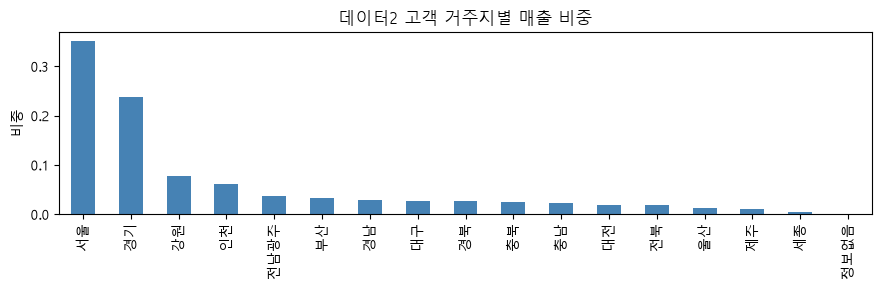

In [14]:
card2 = card2_raw.copy()
card2['TS_AT'] = pd.to_numeric(card2['TS_AT'], errors='coerce')
card2['USE_CNT'] = pd.to_numeric(card2['USE_CNT'], errors='coerce')
card2['AGE_CCD'] = card2['AGE_CCD'].str.replace(' ', '', regex=False)

# 결측·완전중복 현황
# ※ 날짜·업종 열이 없어 서로 다른 날짜·업종의 기록이 같은 값으로 보일 수 있음 → 중복 제거하지 않음
print('빈 값/NaN:', int(card2_raw.eq('').sum().sum()), '/', int(card2[['TS_AT', 'USE_CNT']].isna().sum().sum()))
print(f'완전 중복 행: {card2.duplicated().sum():,} (제거 안 함)')

# 고객 거주지(시도)별 행·매출·건수 비중
res = (card2.groupby('CLN_SGG_CD')
       .agg(행수=('TS_AT', 'size'), 매출=('TS_AT', 'sum'), 건수=('USE_CNT', 'sum')))
res = (res / res.sum()).sort_values('매출', ascending=False)
display(res)

# 성별·연령 분포, 금액·건수 요약
display(pd.crosstab(card2['AGE_CCD'], card2['SEX_CCD'], values=card2['TS_AT'], aggfunc='sum', normalize=True))
display(card2[['TS_AT', 'USE_CNT']].describe().T)

fig, ax = plt.subplots(figsize=(9, 3))
res['매출'].plot.bar(ax=ax, color='steelblue')
ax.set(title='데이터2 고객 거주지별 매출 비중', ylabel='비중', xlabel='')
plt.tight_layout(); plt.show()

## 3. SK 유동인구

### 3-1. 로드
- 목적: 유동인구 3종×6개월 읽기
- TODO: `|` 구분, BLOCK_CD 문자열로 로드 → 종류별 결합
- 확인: 파일별 shape, STD_YM 값

In [15]:
FLOW_KINDS = {'age': '성연령', 'time': '시간대', 'wkdy': '요일'}
MONTHS = [f'2025{m:02d}' for m in range(7, 13)]
FLOW_KEY = ['STD_YM', 'BLOCK_CD', 'X_COORD', 'Y_COORD']   # 정의서상 PK

# 종류 × 월 파일 18개를 읽어 종류별로 결합 (BLOCK_CD는 앞자리 0 보존 위해 문자열)
flow_raw, shape_rows = {}, []
for kind in FLOW_KINDS:
    parts = []
    for ym in MONTHS:
        df = read_zip_csv(contest_zf, contest_idx, f'flow_{kind}_pop_{ym}.csv',
                          sep='|', encoding='utf-8-sig', dtype={'STD_YM': str, 'BLOCK_CD': str})
        shape_rows.append({'종류': kind, '월': ym, '행': len(df), '열': df.shape[1],
                           'STD_YM 값': ','.join(df['STD_YM'].unique())})
        parts.append(df)
    flow_raw[kind] = pd.concat(parts, ignore_index=True)

shapes = pd.DataFrame(shape_rows)
display(shapes.pivot(index='월', columns='종류', values='행'))
print('STD_YM이 파일명과 다른 경우:', (shapes['STD_YM 값'] != shapes['월']).sum())
for kind, df in flow_raw.items():
    print(kind, df.shape, list(df.columns[4:8]), '...')

종류,age,time,wkdy
월,,,
202507,98129,94099,117825
202508,99115,95374,118958
202509,99469,95084,119865
202510,100750,97881,120643
202511,100444,95822,122248
202512,98345,185090,242534


STD_YM이 파일명과 다른 경우: 0
age (596252, 16) ['MAN_FLOW_POP_CNT_10G', 'MAN_FLOW_POP_CNT_20G', 'MAN_FLOW_POP_CNT_30G', 'MAN_FLOW_POP_CNT_40G'] ...
time (663350, 28) ['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03'] ...
wkdy (842073, 11) ['FLOW_POP_CNT_MON', 'FLOW_POP_CNT_TUS', 'FLOW_POP_CNT_WED', 'FLOW_POP_CNT_THU'] ...


### 3-2. 결측 확인·처리
- 목적: 결측·비정상값 처리
- TODO: 열별 결측·음수 집계 → 처리 규칙 적용
- 확인: 처리 전/후 결측 수·행 수

In [16]:
# 값 컬럼 = PK 이외 컬럼
FLOW_VALS = {k: [c for c in df.columns if c not in FLOW_KEY] for k, df in flow_raw.items()}

check = []
for kind, df in flow_raw.items():
    vals = df[FLOW_VALS[kind]]
    check.append({'종류': kind, '키 결측': int(df[FLOW_KEY].isna().sum().sum()),
                  '값 결측': int(vals.isna().sum().sum()), '음수 값': int((vals < 0).sum().sum())})
display(pd.DataFrame(check))

# 처리 규칙
#  - 키 결측: 격자를 특정할 수 없으므로 행 제거
#  - 음수: 인구수로 불가능한 값 → NaN
#  - 값 결측: 0으로 채우지 않고 NaN 유지 (0과 '미관측'을 구분)
flow = {}
for kind, df in flow_raw.items():
    n0 = len(df)
    df = df.dropna(subset=FLOW_KEY).copy()
    df[FLOW_VALS[kind]] = df[FLOW_VALS[kind]].mask(df[FLOW_VALS[kind]] < 0)
    flow[kind] = df
    print(f'{kind}: {n0:,} → {len(df):,}행')

,종류,키 결측,값 결측,음수 값
0,age,0,0,0
1,time,0,0,0
2,wkdy,0,0,0


age: 596,252 → 596,252행


time: 663,350 → 663,350행
wkdy: 842,073 → 842,073행


### 3-3. 중복 확인·제거
- 목적: 12월 중복 행 제거
- TODO: 키(STD_YM·BLOCK_CD·X·Y) 중복 집계 → 제거
- 확인: 전/후 행 수, 월별 행 수 정상화

In [17]:
dup_rows = []
for kind, df in flow.items():
    # 키에 STD_YM이 포함되므로 전체에서 중복 여부를 구한 뒤 월별로 합산
    dup_rows.append(pd.DataFrame({
        '종류': kind,
        '행': df.groupby('STD_YM').size(),
        '완전중복': df.duplicated().groupby(df['STD_YM']).sum(),
        '키중복': df.duplicated(FLOW_KEY).groupby(df['STD_YM']).sum(),
    }))
dup_table = pd.concat(dup_rows).reset_index()
display(dup_table[dup_table['키중복'] > 0])

# 처리 규칙
#  - 완전 중복: 제거 (12월 time·wkdy 파일이 통째로 2번 들어간 형태)
#  - 제거 후에도 키 중복이 남으면(값이 다른 경우) 평균으로 합침
for kind, df in flow.items():
    n0 = len(df)
    df = df.drop_duplicates()
    remain = df.duplicated(FLOW_KEY).sum()
    if remain:
        print(f'  {kind}: 값이 다른 키 중복 {remain}건 → 평균')
        df = df.groupby(FLOW_KEY, as_index=False)[FLOW_VALS[kind]].mean()
    flow[kind] = df.reset_index(drop=True)
    print(f'{kind}: {n0:,} → {len(df):,}행')

# 제거 후 월별 행 수 (12월이 다른 달과 비슷해졌는지)
display(pd.DataFrame({k: df.groupby('STD_YM').size() for k, df in flow.items()}))

,STD_YM,종류,행,완전중복,키중복
11,202512,time,185090,92545,92545
17,202512,wkdy,242534,121267,121267


age: 596,252 → 596,252행


time: 663,350 → 570,805행


wkdy: 842,073 → 720,806행


,age,time,wkdy
STD_YM,,,
202507,98129,94099,117825
202508,99115,95374,118958
202509,99469,95084,119865
202510,100750,97881,120643
202511,100444,95822,122248
202512,98345,92545,121267


### 3-4. 소지역코드·좌표
- 목적: 공간 단위 구조 파악
- TODO: BLOCK_CD 앞자리 분포, 좌표 범위, 3종 간 격자 일치
- 확인: 강남·춘천·경계 밖 격자 수

In [18]:
# BLOCK_CD 앞 5자리 = 통계청 시군구 코드로 추정 (11230 강남구, 32010 춘천시)
SGG_CODE = {'11230': '서울 강남구', '32010': '강원 춘천시'}
for kind, df in flow.items():
    df['SGG5'] = df['BLOCK_CD'].str[:5]
    df['REGION'] = df['SGG5'].map(SGG_CODE).fillna('경계외')

print('BLOCK_CD 길이:', flow['age']['BLOCK_CD'].str.len().unique())
display(pd.crosstab(flow['age']['SGG5'], flow['age']['STD_YM']))  # 경계외 코드는 인접 시군구

# 좌표 범위 (UTM-K) · 격자 간격 확인 (좌표를 50으로 나눈 나머지가 일정하면 50m 격자)
display(flow['age'].groupby('REGION')[['X_COORD', 'Y_COORD']].agg(['min', 'max']))
print('X 좌표 50m 나머지 종류:', flow['age']['X_COORD'].mod(50).round(3).unique()[:5])

# 3종 파일 간 격자 일치 (월별 격자 좌표 집합 비교)
grid_rows = []
for ym in MONTHS:
    cells = {k: set(zip(df.loc[df['STD_YM'] == ym, 'X_COORD'].round(3),
                        df.loc[df['STD_YM'] == ym, 'Y_COORD'].round(3))) for k, df in flow.items()}
    grid_rows.append({'월': ym, **{f'{k} 격자': len(v) for k, v in cells.items()},
                      'age∩time': len(cells['age'] & cells['time']),
                      'time⊂wkdy': cells['time'] <= cells['wkdy']})
display(pd.DataFrame(grid_rows))

# 지역별 격자 수 (8월 성연령 기준)
display(flow['age'][flow['age']['STD_YM'] == '202508']['REGION'].value_counts().to_frame('격자 수'))

BLOCK_CD 길이: [20]


STD_YM,202507,202508,202509,202510,202511,202512
SGG5,,,,,,
11030,1,1,1,1,1,1
11040,1,1,1,1,1,1
11220,8,8,8,8,8,8
11230,15250,15299,15350,15383,15414,15412
11240,1,1,1,1,1,1
31370,16,16,16,17,17,16
32010,82819,83757,84060,85309,84976,82886
32310,13,13,13,13,12,10
32370,18,17,17,15,12,8


X_COORD                     Y_COORD              
                 min           max           min           max
REGION                                                        
강원 춘천시 1,000,583.992 1,046,133.992 1,964,029.147 2,008,279.147
경계외      956,733.992 1,039,183.992 1,941,179.147 2,004,229.147
서울 강남구   956,583.992   966,733.992 1,939,779.147 1,948,579.147

X 좌표 50m 나머지 종류: [33.992]


,월,age 격자,time 격자,wkdy 격자,age∩time,time⊂wkdy
0,202507,98129,94099,117825,92841,True
1,202508,99115,95374,118958,94040,True
2,202509,99469,95084,119865,94059,True
3,202510,100750,97881,120643,95976,True
4,202511,100444,95822,122248,94263,True
5,202512,98345,92545,121267,91210,True


,격자 수
REGION,
강원 춘천시,83757
서울 강남구,15299
경계외,59


### 3-5. 시간·요일·성연령 패턴
- 목적: 유동인구 기본 패턴
- TODO: 지역×월 총량, 시간대 곡선, 요일, 성연령 구조
- 확인: 월별 변화, 8월 특이점

성연령 합계         요일 평균    비율
REGION STD_YM                                  
강원 춘천시 202507 1,796,427.220 1,799,295.590 1.002
       202508 1,860,687.430 1,864,529.199 1.002
       202509 1,954,764.600 1,955,331.576 1.000
       202510 1,889,352.360 1,889,318.637 1.000
       202511 1,861,328.880 1,869,409.659 1.004
       202512 1,774,360.640 1,773,592.289 1.000
서울 강남구 202507 7,542,992.260 7,476,071.233 0.991
       202508 7,184,339.150 7,280,376.531 1.013
       202509 7,599,422.510 7,565,907.160 0.996
       202510 7,132,356.840 7,057,797.099 0.990
       202511 7,459,149.710 7,562,020.269 1.014
       202512 7,320,643.580 7,259,708.036 0.992

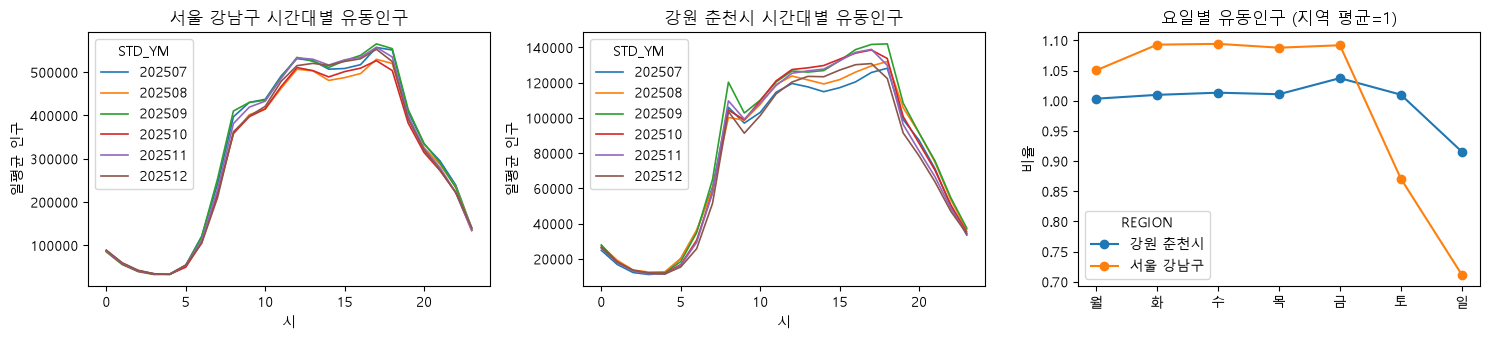

REGION,강원 춘천시,서울 강남구
MAN_FLOW_POP_CNT_10G,0.074,0.044
MAN_FLOW_POP_CNT_20G,0.073,0.066
MAN_FLOW_POP_CNT_30G,0.064,0.098
MAN_FLOW_POP_CNT_40G,0.086,0.110
MAN_FLOW_POP_CNT_50G,0.092,0.097
MAN_FLOW_POP_CNT_60GU,0.120,0.098
WMAN_FLOW_POP_CNT_10G,0.069,0.045
WMAN_FLOW_POP_CNT_20G,0.068,0.088
WMAN_FLOW_POP_CNT_30G,0.061,0.095
WMAN_FLOW_POP_CNT_40G,0.083,0.095


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
서울 강남구,1.014,1.012,1.012,1.008,1.012,0.981,1.009,0.961,0.947,0.973,0.973,0.966,0.971,0.971,0.956,0.950,0.953,0.966,0.979,0.993,1.000,1.013,1.027,1.007
강원 춘천시,1.035,1.061,1.037,1.059,1.067,1.132,1.132,1.012,0.934,1.007,1.009,1.010,0.999,0.981,0.965,0.956,0.958,0.965,1.005,1.055,1.065,1.064,1.054,1.041


In [19]:
REGIONS = ['서울 강남구', '강원 춘천시']
AGE_COLS = FLOW_VALS['age']
TIME_COLS = FLOW_VALS['time']
WKDY_COLS = FLOW_VALS['wkdy']

# 경계외 격자는 제외하고 지역 합계 (값 = 격자별 일평균 유동인구 → 합계 = 지역 일평균)
def region_sum(kind, cols):
    df = flow[kind][flow[kind]['REGION'].isin(REGIONS)]
    return df.groupby(['REGION', 'STD_YM'])[cols].sum()

age_sum, time_sum, wkdy_sum = region_sum('age', AGE_COLS), region_sum('time', TIME_COLS), region_sum('wkdy', WKDY_COLS)

# (1) 월별 총량: 성연령 합계 vs 요일 평균 (정의가 같다면 비슷해야 함)
total = pd.DataFrame({'성연령 합계': age_sum.sum(axis=1), '요일 평균': wkdy_sum.mean(axis=1)})
total['비율'] = total['요일 평균'] / total['성연령 합계']
display(total)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
# (2) 시간대 곡선: 지역별로 월마다 한 줄
for ax, region in zip(axes[:2], REGIONS):
    t = time_sum.loc[region].T
    t.index = range(24)
    t.plot(ax=ax, lw=1.2)
    ax.set(title=f'{region} 시간대별 유동인구', xlabel='시', ylabel='일평균 인구')
# (3) 요일 패턴: 월평균 대비 비율
w = wkdy_sum.groupby('REGION').mean()
(w.div(w.mean(axis=1), axis=0)).T.set_axis(list('월화수목금토일')).plot(ax=axes[2], marker='o')
axes[2].set(title='요일별 유동인구 (지역 평균=1)', ylabel='비율')
plt.tight_layout(); plt.show()

# (4) 성연령 구조: 지역별 6개월 평균 비중
age_share = age_sum.groupby('REGION').mean()
display((age_share.div(age_share.sum(axis=1), axis=0)).T)

# (5) 8월 특이점: 시간대별 8월 값 / 7~12월 평균
aug_ratio = pd.DataFrame({r: time_sum.loc[(r, '202508')] / time_sum.loc[r].mean() for r in REGIONS})
aug_ratio.index = range(24)
display(aug_ratio.T.round(3))

### 3-6. 격자 지도
- 목적: 공간 분포 확인
- TODO: 격자 산점도(색=월평균 유동인구), 지역별
- 확인: 유동 집중 지역

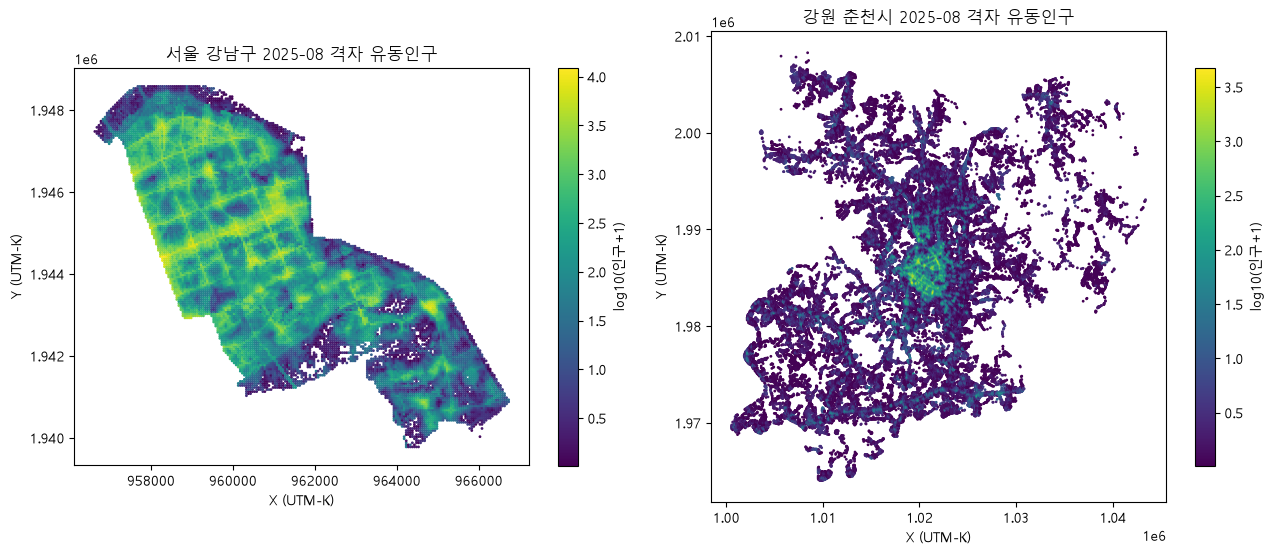

,REGION,BLOCK_CD,X_COORD,Y_COORD,POP
99480,서울 강남구,11230640500030000001,"958,333.992","1,944,429.147","12,383.040"
99391,서울 강남구,11230640300060000002,"958,283.992","1,944,429.147","11,518.650"
99390,서울 강남구,11230640500030000001,"958,283.992","1,944,379.147","10,297.680"
99572,서울 강남구,11230640500030000002,"958,383.992","1,944,429.147","9,625.090"
111845,서울 강남구,11230750400010000002,"964,833.992","1,943,179.147","9,461.660"
99389,서울 강남구,11230640500030000001,"958,283.992","1,944,329.147","9,280.020"
99305,서울 강남구,11230640300060000002,"958,233.992","1,944,429.147","8,529.500"
100862,서울 강남구,11230640400030000007,"958,983.992","1,944,679.147","8,465.200"
101202,서울 강남구,11230650200070000003,"959,133.992","1,944,729.147","8,164.010"
101909,서울 강남구,11230530100030000003,"959,433.992","1,946,579.147","7,894.350"


In [20]:
# 8월 성연령 합계를 격자 산점도로 (색 = log10(일평균 유동인구+1))
aug = flow['age'][(flow['age']['STD_YM'] == '202508') & flow['age']['REGION'].isin(REGIONS)].copy()
aug['POP'] = aug[AGE_COLS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, region in zip(axes, REGIONS):
    d = aug[aug['REGION'] == region]
    sc = ax.scatter(d['X_COORD'], d['Y_COORD'], c=np.log10(d['POP'] + 1), s=1, cmap='viridis')
    ax.set(title=f'{region} 2025-08 격자 유동인구', xlabel='X (UTM-K)', ylabel='Y (UTM-K)')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.7, label='log10(인구+1)')
plt.tight_layout(); plt.show()

# 유동인구 상위 격자 (집중 지역)
display(aug.nlargest(10, 'POP')[['REGION', 'BLOCK_CD', 'X_COORD', 'Y_COORD', 'POP']])

## 4. 기상자료

### 4-1. 지점 선택
- 목적: 분석 대표 지점 확정
- TODO: 관측지점정보.csv 확인 → 강남400·서울108 / 춘천101·북춘천93
- 확인: 지점 좌표·운영기간

In [21]:
# 수집 측 관측지점 정보 (※ AWS 행은 '미수집'으로 적혀 있으나 통합자료 폴더에는 파일이 있음 → 파일 기준으로 확인)
station_info = read_zip_csv(weather_zf, weather_idx, '관측지점정보.csv', encoding='utf-8-sig')
display(station_info[['지점번호', '지점명', '관측종류', '주소', '수집시작일', '수집종료일']])

# 지역별 기본(주) 지점 + 검증용 지점
STATION_MAP = pd.DataFrame([
    {'REGION': '서울 강남구', '역할': '주',   'STATION': '강남_400',  '종류': 'AWS',  '비고': '강남구 일원동, 국지 관측'},
    {'REGION': '서울 강남구', '역할': '검증', 'STATION': '서울_108',  '종류': 'ASOS', '비고': '종로구 송월동, 평년값 계산용'},
    {'REGION': '강원 춘천시', '역할': '주',   'STATION': '춘천_101',  '종류': 'ASOS', '비고': '춘천시 우두동, 평년값 계산용'},
    {'REGION': '강원 춘천시', '역할': '검증', 'STATION': '북춘천_93', '종류': 'ASOS', '비고': '2016-10 신설, 일자료만'},
])

# 통합자료 폴더에 실제 파일이 있는지
integrated = [k.split('/')[-1] for k in weather_idx if '/통합자료/' in k]
STATION_MAP['일자료'] = STATION_MAP['STATION'].map(lambda s: f'{s}_일자료_통합.csv' in integrated)
STATION_MAP['시간자료'] = STATION_MAP['STATION'].map(lambda s: f'{s}_시간자료_통합.csv' in integrated)
display(STATION_MAP)

,지점번호,지점명,관측종류,주소,수집시작일,수집종료일
0,108,서울,종관,서울 종로구 송월동,1975-07-01,2025-12-31
1,101,춘천,종관,강원 춘천시 우두동,1975-07-01,2025-12-31
2,93,북춘천,종관,강원 춘천시 신북읍,2016-10-01,2025-12-31
3,400,강남,방재,서울 강남구 일원동,NaN,NaN
4,401,서초,방재,서울 서초구 서초동,NaN,NaN
5,403,송파,방재,서울 송파구 장지동,NaN,NaN
6,675,남이섬,방재,강원 춘천시 남산면 방하리,NaN,NaN
7,588,남산,방재,강원 춘천시 남산면 방곡리,NaN,NaN


,REGION,역할,STATION,종류,비고,일자료,시간자료
0,서울 강남구,주,강남_400,AWS,"강남구 일원동, 국지 관측",True,True
1,서울 강남구,검증,서울_108,ASOS,"종로구 송월동, 평년값 계산용",True,True
2,강원 춘천시,주,춘천_101,ASOS,"춘천시 우두동, 평년값 계산용",True,True
3,강원 춘천시,검증,북춘천_93,ASOS,"2016-10 신설, 일자료만",True,False


### 4-2. 로드
- 목적: 일·시간자료 읽기
- TODO: 통합자료 csv 로드, 2025-07~12 분리 + 평년용 전체 보관
- 확인: 지점별 기간·행 수

In [22]:
# 원본 컬럼명 → 표준 컬럼명 (ASOS와 AWS의 이름이 달라 통일)
RENAME_HOURLY = {'일시': 'TIME', '기온(C)': 'TEMP', '정시기온(C)': 'TEMP', '시간강수량(mm)': 'RAIN_1H',
                 '1시간강수량(mm)': 'RAIN_1H', '습도(%)': 'HUM', '풍속(m/s)': 'WIND', '강수상태': 'RAIN_STATE'}
RENAME_DAILY = {'일자': 'DATE', '최고기온(C)': 'TMAX', '최저기온(C)': 'TMIN', '평균기온(C)': 'TAVG',
                '일강수량(mm)': 'RAIN', '1시간최다강수량(mm)': 'RAIN_1H_MAX', '평균습도(%)': 'HUM',
                '강수상태': 'RAIN_STATE', '일강수량산출근거': 'RAIN_BASIS', '관측시간수': 'OBS_HOURS'}


def load_weather(station, kind):
    """통합자료 csv 1개 로드 → 표준 컬럼만 남김"""
    df = read_zip_csv(weather_zf, weather_idx, f'통합자료/{station}_{kind}자료_통합.csv',
                      encoding='utf-8-sig', low_memory=False)
    rename = RENAME_HOURLY if kind == '시간' else RENAME_DAILY
    df = df.rename(columns=rename)
    df = df[[c for c in dict.fromkeys(rename.values()) if c in df.columns]].copy()
    time_col = 'TIME' if kind == '시간' else 'DATE'
    df[time_col] = pd.to_datetime(df[time_col])
    df.insert(0, 'STATION', station)
    return df


# 전체 기간(평년 계산용) 로드
wx_hourly_raw = pd.concat([load_weather(s, '시간') for s in STATION_MAP.loc[STATION_MAP['시간자료'], 'STATION']],
                          ignore_index=True)
wx_daily_raw = pd.concat([load_weather(s, '일') for s in STATION_MAP['STATION']], ignore_index=True)

summary = pd.concat([
    wx_hourly_raw.groupby('STATION')['TIME'].agg(['min', 'max', 'size']).add_prefix('시간_'),
    wx_daily_raw.groupby('STATION')['DATE'].agg(['min', 'max', 'size']).add_prefix('일_'),
], axis=1)
display(summary)
print('수집 월:', sorted(wx_daily_raw['DATE'].dt.month.unique()))  # 7~12월만 수집됨

,시간_min,시간_max,시간_size,일_min,일_max,일_size
STATION,,,,,,
강남_400,2015-07-01,2025-12-31 23:00:00,"48,414.000",2015-07-01,2025-12-31,2024
서울_108,1975-07-01,2025-12-31 23:00:00,"225,215.000",1975-07-01,2025-12-31,9384
춘천_101,1975-07-01,2025-12-31 23:00:00,"225,216.000",1975-07-01,2025-12-31,9383
북춘천_93,NaT,NaT,NaN,2016-10-01,2025-12-31,1748


수집 월: [np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


### 4-3. 결측·시각 중복 처리
- 목적: 시계열 정합성 확보
- TODO: 시각 중복·누락 시각·결측값 집계 → 처리
- 확인: 누락 시간 수, 처리 전/후

In [23]:
wx_hourly = wx_hourly_raw.copy()
wx_daily = wx_daily_raw.copy()

# (1) 시각 중복
print('시간자료 시각 중복:', wx_hourly.duplicated(['STATION', 'TIME']).sum(),
      '/ 일자료 날짜 중복:', wx_daily.duplicated(['STATION', 'DATE']).sum())
wx_hourly = wx_hourly.drop_duplicates(['STATION', 'TIME'])
wx_daily = wx_daily.drop_duplicates(['STATION', 'DATE'])


def expected_hours(first_year, last_year=2025):
    """매년 7/1 00시 ~ 12/31 23시 시간 인덱스 (수집 범위와 동일)"""
    return pd.DatetimeIndex(np.concatenate([
        pd.date_range(f'{y}-07-01 00:00', f'{y}-12-31 23:00', freq='h').values
        for y in range(first_year, last_year + 1)]))


def fill_short_gaps(s, max_gap=3):
    """연속 결측이 max_gap시간 이하인 구간만 선형 보간 (긴 결측은 그대로 둠)"""
    isna = s.isna()
    run_len = isna.groupby((isna != isna.shift()).cumsum()).transform('sum')
    return s.where(~(isna & (run_len <= max_gap)), s.interpolate(limit_area='inside'))


# (2) 누락 시각 채우기 + 결측 처리 (지점별)
parts, miss_rows = [], []
for st, g in wx_hourly.groupby('STATION'):
    idx = expected_hours(g['TIME'].dt.year.min())
    g = g.set_index('TIME').reindex(idx).rename_axis('TIME').reset_index()
    g['STATION'] = st
    g['IS_MISSING_ROW'] = g['TEMP'].isna() & g['HUM'].isna() & g['WIND'].isna()  # 행 자체가 없던 시각 포함
    y25 = g['TIME'] >= START
    before = g.loc[y25, ['TEMP', 'HUM', 'RAIN_1H']].isna().sum()

    # 기온·습도: 3시간 이하 결측만 보간, 보간 여부 플래그
    g['TEMP_IMPUTED'] = g['TEMP'].isna()
    for c in ['TEMP', 'HUM']:
        g[c] = fill_short_gaps(g[c])
    g['TEMP_IMPUTED'] &= g['TEMP'].notna()

    # 강수: ASOS는 무강수 시각을 빈 값으로 기록 → 강수상태가 무강수·흔적강수면 0
    if 'RAIN_STATE' in g:
        g.loc[g['RAIN_1H'].isna() & g['RAIN_STATE'].isin(['무강수', '무강수(추정)', '흔적강수']), 'RAIN_1H'] = 0.0

    after = g.loc[y25, ['TEMP', 'HUM', 'RAIN_1H']].isna().sum()
    miss_rows.append({'STATION': st, '2025 누락 시각': int(g.loc[y25, 'IS_MISSING_ROW'].sum()),
                      **before.add_prefix('처리전_').to_dict(), **after.add_prefix('처리후_').to_dict()})
    parts.append(g)
wx_hourly = pd.concat(parts, ignore_index=True)
display(pd.DataFrame(miss_rows))

# (3) 일자료 결측 처리
#  - ASOS 일강수량 빈 값 + 강수상태 무강수·흔적강수 → 0
#  - AWS 관측시간수 20시간 미만인 날은 최고·최저·평균기온을 신뢰할 수 없어 NaN + 플래그
d_before = wx_daily[wx_daily['DATE'] >= START].groupby('STATION')[['TMAX', 'TMIN', 'RAIN']].apply(lambda x: x.isna().sum())
wx_daily.loc[wx_daily['RAIN'].isna() & wx_daily['RAIN_STATE'].isin(['무강수', '흔적강수']), 'RAIN'] = 0.0
wx_daily['PARTIAL_DAY'] = wx_daily['OBS_HOURS'].lt(20).fillna(False)
wx_daily.loc[wx_daily['PARTIAL_DAY'], ['TMAX', 'TMIN', 'TAVG']] = np.nan
d_after = wx_daily[wx_daily['DATE'] >= START].groupby('STATION')[['TMAX', 'TMIN', 'RAIN']].apply(lambda x: x.isna().sum())
display(pd.concat([d_before.add_prefix('처리전_'), d_after.add_prefix('처리후_')], axis=1))
print('AWS 부분관측일(2025):', wx_daily.loc[(wx_daily['DATE'] >= START) & wx_daily['PARTIAL_DAY'], ['STATION', 'DATE', 'OBS_HOURS']].values.tolist())

시간자료 시각 중복: 0 / 일자료 날짜 중복: 0


,STATION,2025 누락 시각,처리전_TEMP,처리전_HUM,처리전_RAIN_1H,처리후_TEMP,처리후_HUM,처리후_RAIN_1H
0,강남_400,34,34,34,68,34,34,68
1,서울_108,0,0,0,3731,0,0,1
2,춘천_101,0,1,0,3853,0,0,1


,처리전_TMAX,처리전_TMIN,처리전_RAIN,처리후_TMAX,처리후_TMIN,처리후_RAIN
STATION,,,,,,
강남_400,0,0,4,2,2,4
북춘천_93,0,0,102,0,0,0
서울_108,0,0,100,0,0,0
춘천_101,0,0,108,0,0,0


AWS 부분관측일(2025): [['강남_400', Timestamp('2025-09-11 00:00:00'), 7.0], ['강남_400', Timestamp('2025-09-10 00:00:00'), 8.0]]


### 4-4. 극값 일수
- 목적: 2025 하반기 극한 기상 규모
- TODO: 폭염(33·35℃)·열대야·호우·한파(-10℃) 일수, 35℃ 이상 시간 수
- 확인: 지점별 극값 표

,폭염33,폭염35,열대야25,한파_10,한파_15,호우30,호우80,최고기온,최저기온,노출_33도이상_시간,노출_35도이상_시간
STATION,,,,,,,,,,,
강남_400,33,15,44,1,0,10,1,38.200,-10.600,192.000,75.000
북춘천_93,28,13,4,7,0,14,1,37.200,-14.500,NaN,NaN
서울_108,25,13,44,1,0,15,2,38.000,-11.800,145.000,63.000
춘천_101,30,11,5,4,0,18,1,37.100,-13.400,111.000,37.000


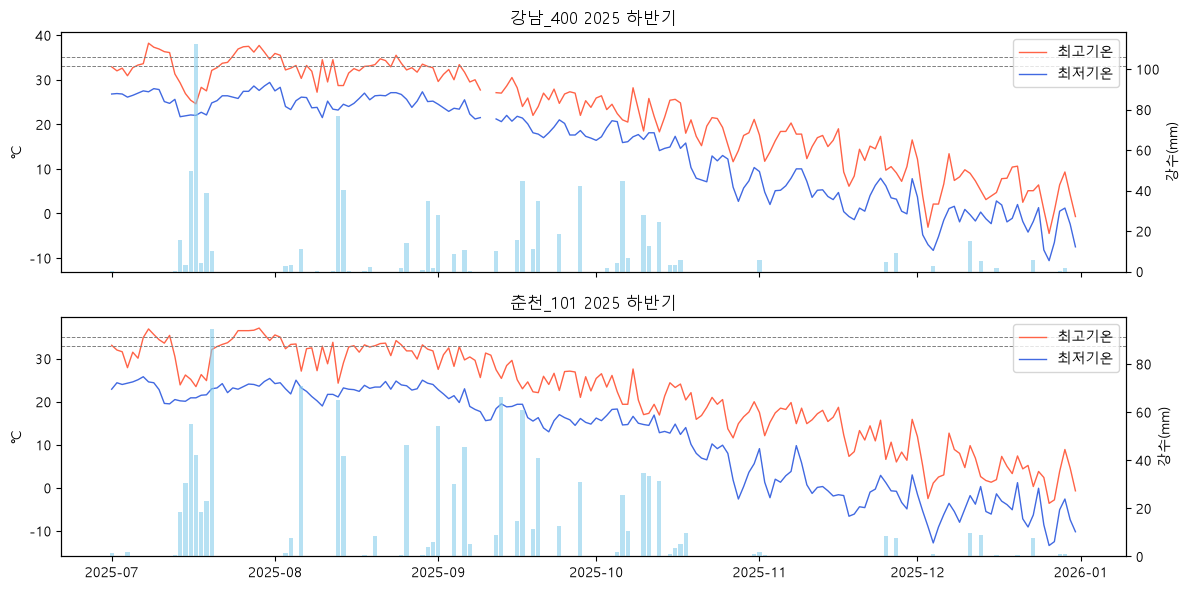

In [24]:
# 2025 하반기 일자료 기준 극값 일수
d25 = wx_daily[wx_daily['DATE'] >= START]
extreme = d25.groupby('STATION').agg(
    폭염33=('TMAX', lambda x: (x >= 33).sum()), 폭염35=('TMAX', lambda x: (x >= 35).sum()),
    열대야25=('TMIN', lambda x: (x >= 25).sum()), 한파_10=('TMIN', lambda x: (x <= -10).sum()),
    한파_15=('TMIN', lambda x: (x <= -15).sum()), 호우30=('RAIN', lambda x: (x >= 30).sum()),
    호우80=('RAIN', lambda x: (x >= 80).sum()), 최고기온=('TMAX', 'max'), 최저기온=('TMIN', 'min'),
)

# 시간자료 기준 노출 시간 (논문처럼 0~5시 제외, 06~23시만)
h25 = wx_hourly[(wx_hourly['TIME'] >= START) & (wx_hourly['TIME'].dt.hour >= 6)]
exposure = h25.groupby('STATION')['TEMP'].agg(
    노출_33도이상_시간=lambda x: (x >= 33).sum(), 노출_35도이상_시간=lambda x: (x >= 35).sum())
display(extreme.join(exposure))

# 주 지점 일 최고기온·강수 추이
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, st in zip(axes, ['강남_400', '춘천_101']):
    d = d25[d25['STATION'] == st]
    ax.plot(d['DATE'], d['TMAX'], color='tomato', lw=1, label='최고기온')
    ax.plot(d['DATE'], d['TMIN'], color='royalblue', lw=1, label='최저기온')
    for t in [33, 35]:
        ax.axhline(t, color='gray', ls='--', lw=0.7)
    ax2 = ax.twinx()
    ax2.bar(d['DATE'], d['RAIN'], color='skyblue', alpha=0.6)
    ax2.set_ylabel('강수(mm)')
    ax.set(title=f'{st} 2025 하반기', ylabel='℃')
    ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### 4-5. 평년 편차
- 목적: 이례성 판단
- TODO: 1991~2020 일별 평년값 → 2025 편차
- 확인: 이례적 날짜 목록

TMAX_ANOM        TMIN_ANOM       
STATION    서울_108 춘천_101    서울_108 춘천_101
DATE                                     
7           3.540  2.870     3.350  1.690
8           1.950  2.040     2.400  1.750
9           1.170  1.280     2.560  2.370
10          0.210  0.450     2.490  3.770
11          2.320  2.670     1.120 -0.320
12          1.050  0.670     0.540  0.890

,평년 폭염33 일수(연),2025 폭염33 일수
STATION,,
서울_108,8.100,25
춘천_101,9.767,30


[서울_108] 더운 날 상위 / 추운 날 상위


,DATE,TMAX,TMAX_NORMAL,TMAX_ANOM,DATE,TMIN,TMIN_NORMAL,TMIN_ANOM
0,2025-07-08,37.800,28.711,9.089,2025-12-04,-9.400,-1.736,-7.664
1,2025-11-30,16.100,7.751,8.349,2025-12-26,-11.800,-4.534,-7.266
2,2025-12-07,13.400,5.183,8.217,2025-12-03,-8.100,-1.398,-6.702
3,2025-07-12,36.500,28.396,8.104,2025-11-03,0.500,6.453,-5.953
4,2025-07-27,38.000,30.000,8.000,2025-10-21,4.800,9.888,-5.088
5,2025-07-10,36.200,28.494,7.706,2025-12-05,-6.900,-2.019,-4.881
6,2025-07-11,36.100,28.471,7.629,2025-12-25,-8.900,-4.160,-4.740
7,2025-11-16,18.700,11.165,7.535,2025-10-20,5.300,10.011,-4.711


[춘천_101] 더운 날 상위 / 추운 날 상위


,DATE,TMAX,TMAX_NORMAL,TMAX_ANOM,DATE,TMIN,TMIN_NORMAL,TMIN_ANOM
0,2025-11-30,15.900,6.922,8.978,2025-12-04,-12.800,-4.613,-8.187
1,2025-12-07,12.700,4.345,8.355,2025-10-28,-2.600,3.842,-6.442
2,2025-11-16,18.700,10.626,8.074,2025-12-26,-13.400,-7.664,-5.736
3,2025-07-08,36.900,28.898,8.002,2025-11-18,-6.600,-1.034,-5.566
4,2025-11-24,15.700,8.140,7.560,2025-11-03,-2.300,2.724,-5.024
5,2025-12-29,8.900,1.660,7.240,2025-12-03,-9.000,-4.238,-4.762
6,2025-07-12,35.400,28.485,6.915,2025-11-19,-6.100,-1.363,-4.737
7,2025-07-09,35.600,28.703,6.897,2025-12-27,-12.500,-8.172,-4.328


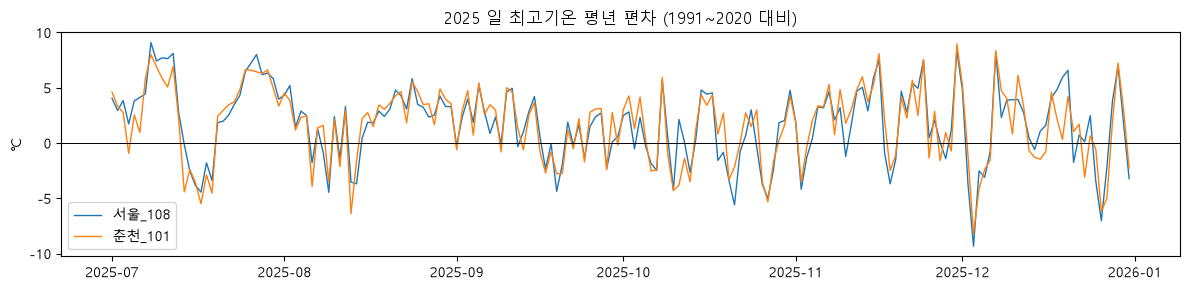

In [25]:
# 평년값: 1991~2020년 30년, ASOS 지점만 (AWS는 2015년부터라 불가)
NORMAL_STATIONS = ['서울_108', '춘천_101']
base = wx_daily[wx_daily['STATION'].isin(NORMAL_STATIONS) & wx_daily['DATE'].dt.year.between(1991, 2020)].copy()
base['MD'] = base['DATE'].dt.strftime('%m-%d')

# 월-일별 평균 → 7일 이동평균으로 날짜별 들쭉날쭉함 완화
normals = (base.groupby(['STATION', 'MD'])[['TMAX', 'TMIN', 'RAIN']].mean()
           .groupby('STATION', group_keys=False)
           .apply(lambda x: x.rolling(7, center=True, min_periods=1).mean())
           .add_suffix('_NORMAL').reset_index())

# 2025 편차
anom = wx_daily[wx_daily['STATION'].isin(NORMAL_STATIONS) & (wx_daily['DATE'] >= START)].copy()
anom['MD'] = anom['DATE'].dt.strftime('%m-%d')
anom = anom.merge(normals, on=['STATION', 'MD'], how='left')
anom['TMAX_ANOM'] = anom['TMAX'] - anom['TMAX_NORMAL']
anom['TMIN_ANOM'] = anom['TMIN'] - anom['TMIN_NORMAL']

# 월별 평균 편차 + 평년 폭염일수(연평균) vs 2025
display(anom.groupby(['STATION', anom['DATE'].dt.month])[['TMAX_ANOM', 'TMIN_ANOM']].mean().unstack(0).round(2))
normal_hot = base.groupby('STATION')['TMAX'].apply(lambda x: (x >= 33).sum() / 30).rename('평년 폭염33 일수(연)')
display(pd.concat([normal_hot, extreme.loc[NORMAL_STATIONS, '폭염33'].rename('2025 폭염33 일수')], axis=1))

# 이례적 날짜: 최고기온 편차 상위 · 최저기온 편차 하위
for st in NORMAL_STATIONS:
    a = anom[anom['STATION'] == st]
    print(f'[{st}] 더운 날 상위 / 추운 날 상위')
    display(pd.concat([a.nlargest(8, 'TMAX_ANOM')[['DATE', 'TMAX', 'TMAX_NORMAL', 'TMAX_ANOM']].reset_index(drop=True),
                       a.nsmallest(8, 'TMIN_ANOM')[['DATE', 'TMIN', 'TMIN_NORMAL', 'TMIN_ANOM']].reset_index(drop=True)], axis=1))

fig, ax = plt.subplots(figsize=(12, 3))
for st, g in anom.groupby('STATION'):
    ax.plot(g['DATE'], g['TMAX_ANOM'], lw=1, label=st)
ax.axhline(0, color='k', lw=0.7)
ax.set(title='2025 일 최고기온 평년 편차 (1991~2020 대비)', ylabel='℃')
ax.legend(); plt.tight_layout(); plt.show()

### 4-6. 지점 비교
- 목적: 대표 지점 타당성 점검
- TODO: 강남400 vs 서울108, 춘천101 vs 북춘천93 기온 차·상관
- 확인: 지점 간 차이 크기

[강남 vs 서울] 평균차 +0.40℃, 상관 0.997, 35℃ 이상 시간: 강남 75 / 서울 63
[춘천 vs 북춘천 TMAX] 평균차 +0.39℃, 상관 0.999
[춘천 vs 북춘천 TMIN] 평균차 +0.36℃, 상관 0.999
폭염33 일수: 춘천 30 / 북춘천 28


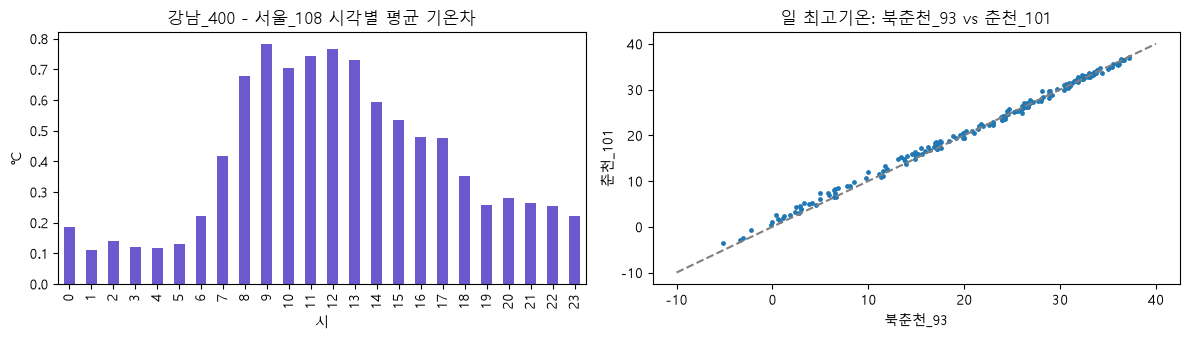

In [26]:
# (1) 강남_400 vs 서울_108: 2025 시간 기온
h = (wx_hourly[wx_hourly['TIME'] >= START]
     .pivot(index='TIME', columns='STATION', values='TEMP')[['강남_400', '서울_108']].dropna())
diff = h['강남_400'] - h['서울_108']
print(f'[강남 vs 서울] 평균차 {diff.mean():+.2f}℃, 상관 {h.corr().iloc[0, 1]:.3f}, '
      f'35℃ 이상 시간: 강남 {(h["강남_400"] >= 35).sum()} / 서울 {(h["서울_108"] >= 35).sum()}')

# (2) 춘천_101 vs 북춘천_93: 2025 일 최고·최저
d = (wx_daily[wx_daily['DATE'] >= START]
     .pivot(index='DATE', columns='STATION', values=['TMAX', 'TMIN']))
for v in ['TMAX', 'TMIN']:
    pair = d[v][['춘천_101', '북춘천_93']].dropna()
    print(f'[춘천 vs 북춘천 {v}] 평균차 {(pair["춘천_101"] - pair["북춘천_93"]).mean():+.2f}℃, '
          f'상관 {pair.corr().iloc[0, 1]:.3f}')
print('폭염33 일수: 춘천', int((d['TMAX']['춘천_101'] >= 33).sum()), '/ 북춘천', int((d['TMAX']['북춘천_93'] >= 33).sum()))

# 시각별 평균 기온차: 낮/밤 중 언제 차이가 큰지
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
diff.groupby(diff.index.hour).mean().plot.bar(ax=axes[0], color='slateblue')
axes[0].set(title='강남_400 - 서울_108 시각별 평균 기온차', xlabel='시', ylabel='℃')
axes[1].scatter(d['TMAX']['북춘천_93'], d['TMAX']['춘천_101'], s=6)
axes[1].plot([-10, 40], [-10, 40], color='gray', ls='--')
axes[1].set(title='일 최고기온: 북춘천_93 vs 춘천_101', xlabel='북춘천_93', ylabel='춘천_101')
plt.tight_layout(); plt.show()

## 5. 달력

### 5-1. 공휴일·이벤트
- 목적: 달력 교란 요인 정리
- TODO: 2025 하반기 공휴일·대체휴일·추석 연휴·월말 플래그 테이블
- 확인: 달력 테이블

In [27]:
# 2025 하반기 공휴일 (관공서 공휴일 기준, 필요 시 수정)
HOLIDAYS = {
    '2025-08-15': '광복절', '2025-10-03': '개천절', '2025-10-05': '추석 연휴', '2025-10-06': '추석',
    '2025-10-07': '추석 연휴', '2025-10-08': '대체공휴일(추석)', '2025-10-09': '한글날', '2025-12-25': '성탄절',
}

calendar = pd.DataFrame({'DATE': ALL_DAYS})
calendar['MONTH'] = calendar['DATE'].dt.month
calendar['DOW'] = calendar['DATE'].dt.dayofweek                        # 0=월 ~ 6=일
calendar['DOW_KR'] = calendar['DOW'].map(dict(enumerate('월화수목금토일')))
calendar['IS_WEEKEND'] = calendar['DOW'] >= 5
calendar['HOLIDAY_NAME'] = calendar['DATE'].dt.strftime('%Y-%m-%d').map(HOLIDAYS)
calendar['IS_HOLIDAY'] = calendar['HOLIDAY_NAME'].notna()
calendar['IS_OFFDAY'] = calendar['IS_WEEKEND'] | calendar['IS_HOLIDAY']   # 쉬는 날
calendar['IS_CHUSEOK_PERIOD'] = calendar['DATE'].between('2025-10-03', '2025-10-09')  # 개천절~한글날 연휴
calendar['DAYS_TO_MONTH_END'] = (calendar['DATE'] + pd.offsets.MonthEnd(0) - calendar['DATE']).dt.days
calendar['IS_MONTH_END'] = calendar['DAYS_TO_MONTH_END'] <= 2              # 월말 3일 (급여·결제일 효과)
calendar['IS_YEAR_END'] = calendar['DATE'] >= '2025-12-24'                 # 성탄~연말

display(calendar[calendar['IS_HOLIDAY'] | calendar['IS_CHUSEOK_PERIOD']])
display(calendar.groupby('MONTH')[['IS_WEEKEND', 'IS_HOLIDAY', 'IS_OFFDAY']].sum())

,DATE,MONTH,DOW,DOW_KR,IS_WEEKEND,HOLIDAY_NAME,IS_HOLIDAY,IS_OFFDAY,IS_CHUSEOK_PERIOD,DAYS_TO_MONTH_END,IS_MONTH_END,IS_YEAR_END
45,2025-08-15,8,4,금,False,광복절,True,True,False,16,False,False
94,2025-10-03,10,4,금,False,개천절,True,True,True,28,False,False
95,2025-10-04,10,5,토,True,NaN,False,True,True,27,False,False
96,2025-10-05,10,6,일,True,추석 연휴,True,True,True,26,False,False
97,2025-10-06,10,0,월,False,추석,True,True,True,25,False,False
98,2025-10-07,10,1,화,False,추석 연휴,True,True,True,24,False,False
99,2025-10-08,10,2,수,False,대체공휴일(추석),True,True,True,23,False,False
100,2025-10-09,10,3,목,False,한글날,True,True,True,22,False,False
177,2025-12-25,12,3,목,False,성탄절,True,True,False,6,False,True


,IS_WEEKEND,IS_HOLIDAY,IS_OFFDAY
MONTH,,,
7,8,0,8
8,10,1,11
9,8,0,8
10,8,6,13
11,10,0,10
12,8,1,9


## 6. 저장·요약

### 6-1. 저장
- 목적: 02 노트북 입력 생성
- TODO: 카드·데이터2·유동인구·기상·달력 → `preprocessed/` 저장 (parquet 불가 시 pickle)
- 확인: 저장 파일 목록·크기

In [28]:
# 계산용 임시 컬럼 정리 후 저장 (pyarrow 미설치 → pickle, 사람이 볼 표는 csv)
flow_out = {k: df.drop(columns='SGG5') for k, df in flow.items()}

outputs = {
    'card1.pkl': card1,                     # 카드 데이터1 (플래그: IS_CORP·IS_OUTLIER·PAPER_GROUP·IS_PLACEBO·IS_RETAIL)
    'card2.pkl': card2,                     # 카드 데이터2 (부록, 원형 유지)
    'flow_age.pkl': flow_out['age'],        # 유동인구 성연령 (중복 제거, REGION 부여)
    'flow_time.pkl': flow_out['time'],      # 유동인구 시간대
    'flow_wkdy.pkl': flow_out['wkdy'],      # 유동인구 요일
    'wx_hourly.pkl': wx_hourly,             # 기상 시간자료 (누락 시각 복원·단기 보간)
    'wx_daily.pkl': wx_daily,               # 기상 일자료 (강수 0 처리·부분관측일 플래그)
    'wx_normals.pkl': normals,              # 평년값 (1991~2020, ASOS)
    'calendar.pkl': calendar,               # 달력 교란 요인
}
for name, obj in outputs.items():
    obj.to_pickle(OUT_DIR / name)

industry_map.to_csv(OUT_DIR / 'industry_map.csv', index=False, encoding='utf-8-sig')
STATION_MAP.to_csv(OUT_DIR / 'station_map.csv', index=False, encoding='utf-8-sig')

display(pd.DataFrame([{'파일': p.name, 'MB': p.stat().st_size / 1e6} for p in sorted(OUT_DIR.iterdir())]))

,파일,MB
0,calendar.pkl,0.009
1,card1.pkl,43.882
2,card2.pkl,56.222
3,flow_age.pkl,74.248
4,flow_time.pkl,125.752
5,flow_wkdy.pkl,60.696
6,industry_map.csv,0.004
7,station_map.csv,0.000
8,wx_daily.pkl,1.760
9,wx_hourly.pkl,23.299


### 6-2. 이슈·처리 내역
- 목적: 한계 기록
- TODO: 발견 이슈와 처리 방법 표 작성
- 확인: 02에서 참고할 한계 목록

In [29]:
# 이 노트북에서 발견한 이슈와 처리 방법 (수치는 위 셀 결과에서 가져옴)
corp_sales = card1.loc[card1['IS_CORP'], 'TS_AT'].sum() / card1['TS_AT'].sum()
flow_dec_dup = int(dup_table.loc[dup_table['키중복'] > 0, '키중복'].sum())
aws_missing = ', '.join(f"{r['STATION']} {r['2025 누락 시각']}시간" for r in miss_rows if r['2025 누락 시각'] > 0)
issues = pd.DataFrame([
    ('카드1', '결측·중복', f"결측 0 / 완전중복 {full_dup:,}", '규칙만 적용(해당 없음)', '-'),
    ('카드1', '법인 결제 포함', f'매출 {corp_sales:.1%}', 'IS_CORP 플래그', '기본은 개인 결제만 사용'),
    ('카드1', '5건 미만 절단', f"최솟값 {card1['USE_CNT'].min()}건", '처리 불가, 기록', '소규모 업종·심야 과소집계'),
    ('카드1', '극단 금액', f"{card1['IS_OUTLIER'].sum():,}행", 'IS_OUTLIER 플래그', '포함/제외 민감도 비교'),
    ('카드1', '비날씨 결제 비중 큼', '세금공과금·ZZ_나머지 등', 'IS_PLACEBO 대조군', '소매범위에서 제외'),
    ('카드1', '데이터 부족 업종', f"보류 {(ind_stat['등급'] == '보류').sum()}건(업종×지역)", '등급 부여', 'A/B 등급만 일별 분석'),
    ('카드2', '날짜·가맹점지역·업종 열 없음', f'{len(card2):,}행', '부록 기술통계만', '기상 분석 불가'),
    ('유동인구', '12월 time·wkdy 전체 중복', f'{flow_dec_dup:,}행', '완전중복 제거', '-'),
    ('유동인구', '월 단위 집계', '일별 값 없음', '-', '일별 기상과 직접 결합 불가'),
    ('유동인구', '경계외 격자 포함', '인접 시군구 코드', 'REGION=경계외', '지역 합계에서 제외'),
    ('기상', '누락 시각(2025)', aws_missing or '없음', '3시간 이하만 보간', 'TEMP_IMPUTED 참고'),
    ('기상', 'ASOS 무강수 빈 값', '강수상태로 판별', '0으로 채움', '-'),
    ('기상', 'AWS 부분관측일', 'OBS_HOURS < 20', '기온 NaN + PARTIAL_DAY', '해당일 노출변수 결측'),
    ('기상', '한파 기준 미달', f"최저 {extreme['최저기온'].min():.1f}℃", '-', '논문 −15℃ 한파 검증 불가'),
    ('기상', '평년값', 'AWS 2015년~', 'ASOS로만 계산', '강남 편차는 서울_108로 대체'),
    ('달력', '추석 연휴 10/3~10/9', '7일', 'IS_CHUSEOK_PERIOD', '기준선에서 통제'),
], columns=['데이터', '이슈', '규모', '처리', '02에서의 영향'])
display(issues)

,데이터,이슈,규모,처리,02에서의 영향
0,카드1,결측·중복,결측 0 / 완전중복 0,규칙만 적용(해당 없음),-
1,카드1,법인 결제 포함,매출 15.9%,IS_CORP 플래그,기본은 개인 결제만 사용
2,카드1,5건 미만 절단,최솟값 5건,"처리 불가, 기록",소규모 업종·심야 과소집계
3,카드1,극단 금액,"2,175행",IS_OUTLIER 플래그,포함/제외 민감도 비교
4,카드1,비날씨 결제 비중 큼,세금공과금·ZZ_나머지 등,IS_PLACEBO 대조군,소매범위에서 제외
5,카드1,데이터 부족 업종,보류 13건(업종×지역),등급 부여,A/B 등급만 일별 분석
6,카드2,날짜·가맹점지역·업종 열 없음,"1,806,800행",부록 기술통계만,기상 분석 불가
7,유동인구,12월 time·wkdy 전체 중복,"213,812행",완전중복 제거,-
8,유동인구,월 단위 집계,일별 값 없음,-,일별 기상과 직접 결합 불가
9,유동인구,경계외 격자 포함,인접 시군구 코드,REGION=경계외,지역 합계에서 제외
